# 11 Mask-Guided ResNet18 Gated Attention: T1c + T2F, No Mask Input

Same raw guided-cache pipeline and training strategy as notebook 10, but the model is MONAI 3D ResNet18 with GroupNorm and gated attention pooling. The model input is always MRI only (`T1c + T2F/FLAIR`). Masks are used only during training as auxiliary attention guidance and for sanity checks/Grad-CAM comparison.


##Getting Data

In [ ]:
# Run once in fresh Colab if needed.
!pip install -q "monai[nibabel]" scikit-learn matplotlib pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

MODEL_NAME = "Mask-guided ResNet18 Gated Attention T1c+T2F raw-cache112"
OUTPUT_DIR = "/content/drive/MyDrive/final_gli_men_3d_outputs_t1c_t2f/mask_guided_resnet18_gated_attention_raw_cache112"
BEST_CKPT_NAME = "best_mask_guided_resnet18_gated_attention_t1c_t2f_raw112.pt"

# Raw source data. Use TRAINING folders only because BraTS validation folders do not include masks.
RAW_DATA_ROOT = "/content/drive/MyDrive/Brats_Final_Data"
RAW_SPLIT_FOLDERS = [
    ("ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData", "glioma"),
    ("ASNR-MICCAI-BraTS2023-MEN-Challenge-TrainingData", "meningioma"),
]

# Persistent cache built once from raw data. Future runs reuse it.
GUIDED_CACHE_ROOT = "/content/drive/MyDrive/mri_preprocessed_cache_brats_gli_men_t1c_t2f_mask_guided112_rawtrain_v1"
OVERWRITE_GUIDED_CACHE = False
CACHE_BUILD_MAX_WORKERS = 2
CACHE_COMPRESSED = True

CORRUPT_PATIENT_IDS = {"BraTS-GLI-00003-000"}
CORRUPT_GROUP_IDS = {"BraTS-GLI-00003"}
SHARED_SPLIT_MANIFEST = "/content/drive/MyDrive/final_gli_men_3d_outputs_t1c_t2f/fair_split_manifest_rawtrain_guided112_dedup_no00003.json"

TRAIN_SPATIAL_SIZE = (112, 112, 112)
INPUT_CHANNELS = 2
CLASS_TO_INDEX = {"glioma": 0, "meningioma": 1}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}
TRAIN_FRACTION, VAL_FRACTION, TEST_FRACTION = 0.70, 0.15, 0.15
RANDOM_SEED = 42

BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4
NUM_WORKERS = 2
EPOCHS = 45
LEARNING_RATE = 3.0e-4
MIN_LR = 1e-7
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 4
EARLY_STOPPING_PATIENCE = 9
LABEL_SMOOTHING = 0.03
MAX_GRAD_NORM = 1.0
USE_AMP = True

REQUIRE_BALANCED_TRAIN_MASKS = True
MIN_MASKS_PER_CLASS_FOR_GUIDANCE = 10
MASK_DROPOUT_PROB = 0.40
ATTN_GUIDANCE_WEIGHT = 0.35
ATTN_OUTSIDE_WEIGHT = 0.15
COUNTERFACTUAL_CONSISTENCY_WEIGHT = 0.08
COUNTERFACTUAL_PROB = 0.35
CLASSIFIER_DROPOUT = 0.25
RESNET_NO_MAX_POOL = False

print("MODEL:", MODEL_NAME)
print("RAW_DATA_ROOT:", RAW_DATA_ROOT)
print("GUIDED_CACHE_ROOT:", GUIDED_CACHE_ROOT)
print("Target cache size:", TRAIN_SPATIAL_SIZE)
print("Model input: MRI only [T1c, T2F/FLAIR]. Mask is training guidance only.")


Mounted at /content/drive
MODEL: Mask-guided ResNet18 Gated Attention T1c+T2F raw-cache112
RAW_DATA_ROOT: /content/drive/MyDrive/Brats_Final_Data
GUIDED_CACHE_ROOT: /content/drive/MyDrive/mri_preprocessed_cache_brats_gli_men_t1c_t2f_mask_guided112_rawtrain_v1
Target cache size: (112, 112, 112)
Model input: MRI only [T1c, T2F/FLAIR]. Mask is training guidance only.


##Pre-Processing and Creating Dataset

In [ ]:
import json, math, os, random, re, time
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter, zoom
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from monai.networks.nets import resnet18
from monai.transforms import Compose, EnsureTyped, RandFlipd, RandGaussianNoised, RandScaleIntensityd, RandShiftIntensityd


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Existing guided cache is expected to be ready; do not create an empty root here.
print("Device:", DEVICE)


@dataclass(frozen=True)
class RawRecord:
    t1c_path: str
    t2f_path: str
    mask_path: str
    label_index: int
    class_name: str
    patient_id: str
    group_id: str


@dataclass(frozen=True)
class MRIRecord:
    path: str
    label_index: int
    class_name: str
    patient_id: str
    group_id: str
    has_mask: bool = True


def group_id_from_patient_id(patient_id):
    return re.sub(r"-\d{3}$", "", patient_id)


def canonical_patient_id(name):
    name = re.sub(r"\.nii(\.gz)?$", "", name, flags=re.IGNORECASE)
    name = re.sub(r"[-_](t1c|t1ce|t1gd|t2f|flair|t2w-flair|seg|mask|label)$", "", name, flags=re.IGNORECASE)
    return name


def find_first_file(folder, includes, suffixes=(".nii.gz", ".nii")):
    folder = Path(folder)
    hits = []
    for pth in folder.rglob("*"):
        low = pth.name.lower()
        if pth.is_file() and low.endswith(suffixes) and any(s in low for s in includes):
            hits.append(pth)
    return str(sorted(hits)[0]) if hits else None


def discover_raw_training_records():
    root = Path(RAW_DATA_ROOT)
    if not root.exists():
        raise FileNotFoundError(f"RAW_DATA_ROOT does not exist: {root}")

    records, missing = [], []
    seen_groups = set()
    skipped_duplicate, skipped_corrupt = [], []

    for folder_name, class_name in RAW_SPLIT_FOLDERS:
        class_root = root / folder_name
        if not class_root.exists():
            raise FileNotFoundError(f"Missing raw folder: {class_root}")
        case_dirs = sorted([x for x in class_root.iterdir() if x.is_dir()])
        print(f"Scanning {folder_name} ({class_name}): {len(case_dirs)} case folders")
        for case_dir in case_dirs:
            t1c = find_first_file(case_dir, ("t1c", "t1ce", "t1gd", "contrast"))
            t2f = find_first_file(case_dir, ("t2f", "flair", "t2w-flair"))
            seg = find_first_file(case_dir, ("seg", "mask", "label"))
            if not (t1c and t2f and seg):
                missing.append((case_dir.name, bool(t1c), bool(t2f), bool(seg)))
                continue
            pid = canonical_patient_id(Path(t1c).name)
            if len(pid) < 8:
                pid = case_dir.name
            gid = group_id_from_patient_id(pid)
            if pid in CORRUPT_PATIENT_IDS or gid in CORRUPT_GROUP_IDS:
                skipped_corrupt.append(pid)
                continue
            key = (class_name, gid)
            if key in seen_groups:
                skipped_duplicate.append(pid)
                continue
            seen_groups.add(key)
            records.append(
                RawRecord(
                    t1c_path=t1c,
                    t2f_path=t2f,
                    mask_path=seg,
                    label_index=CLASS_TO_INDEX[class_name],
                    class_name=class_name,
                    patient_id=pid,
                    group_id=gid,
                )
            )

    print("Raw records:", len(records), dict(Counter(r.class_name for r in records)))
    print("Missing t1c/t2f/seg cases:", len(missing))
    if missing:
        print("First missing:", missing[:10])
    print("Skipped corrupted:", len(skipped_corrupt))
    print("Skipped duplicate groups:", len(skipped_duplicate))
    if skipped_duplicate:
        print("First duplicate skips:", skipped_duplicate[:10])
    if not records:
        raise FileNotFoundError("No raw training cases with T1c + T2F/FLAIR + seg were found.")
    return sorted(records, key=lambda r: (r.label_index, r.patient_id))


def robust_normalize(channel):
    channel = np.asarray(channel, dtype=np.float32)
    foreground = np.abs(channel) > 1e-6
    if np.count_nonzero(foreground) < 32:
        return np.zeros_like(channel, dtype=np.float32)
    vals = channel[foreground]
    lo, hi = np.percentile(vals, [0.5, 99.5])
    if hi - lo < 1e-6:
        return np.zeros_like(channel, dtype=np.float32)
    clipped = np.clip(channel, lo, hi)
    vals = clipped[foreground]
    mean = float(vals.mean())
    std = max(float(vals.std()), 1e-6)
    out = np.zeros_like(channel, dtype=np.float32)
    out[foreground] = (clipped[foreground] - mean) / std
    return out.astype(np.float32)


def load_nifti_array(path):
    img = nib.load(path)
    img = nib.as_closest_canonical(img)
    arr = np.asarray(img.get_fdata(), dtype=np.float32)
    if arr.ndim == 4:
        arr = arr[..., 0]
    return arr.astype(np.float32)


def resize_3d(arr, target_shape, order):
    factors = [float(t) / float(s) for s, t in zip(arr.shape, target_shape)]
    return zoom(arr, zoom=factors, order=order).astype(np.float32)


def expected_cache_path(rec):
    return str(Path(GUIDED_CACHE_ROOT) / rec.class_name / f"{rec.patient_id}_t1c_t2f_mask_guided112.npz")


def cache_file_is_valid(path):
    try:
        with np.load(path) as data:
            return (
                tuple(data["image"].shape) == (2,) + tuple(TRAIN_SPATIAL_SIZE)
                and tuple(data["mask"].shape) == (1,) + tuple(TRAIN_SPATIAL_SIZE)
                and tuple(data["tumor_soft"].shape) == (1,) + tuple(TRAIN_SPATIAL_SIZE)
                and int(data["has_mask"]) == 1
                and float(data["mask"].sum()) > 0
            )
    except Exception:
        return False


def preprocess_one_raw_case(rec):
    out_path = expected_cache_path(rec)
    if os.path.exists(out_path) and not OVERWRITE_GUIDED_CACHE and cache_file_is_valid(out_path):
        return MRIRecord(out_path, rec.label_index, rec.class_name, rec.patient_id, rec.group_id, True)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    t1c = robust_normalize(resize_3d(load_nifti_array(rec.t1c_path), TRAIN_SPATIAL_SIZE, order=1))
    t2f = robust_normalize(resize_3d(load_nifti_array(rec.t2f_path), TRAIN_SPATIAL_SIZE, order=1))
    mask = resize_3d(load_nifti_array(rec.mask_path), TRAIN_SPATIAL_SIZE, order=0)
    mask = (mask > 0).astype(np.uint8)
    if int(mask.sum()) <= 0:
        raise ValueError(f"{rec.patient_id}: empty mask after preprocessing")
    tumor_soft = gaussian_filter(mask.astype(np.float32), sigma=1.5)
    if float(tumor_soft.max()) > 1e-6:
        tumor_soft = tumor_soft / float(tumor_soft.max())

    image = np.stack([t1c, t2f], axis=0).astype(np.float16)
    tmp_path = out_path + ".tmp"
    save_fn = np.savez_compressed if CACHE_COMPRESSED else np.savez
    save_fn(
        tmp_path,
        image=image,
        mask=mask[None].astype(np.uint8),
        tumor_soft=tumor_soft[None].astype(np.float16),
        has_mask=np.int64(1),
        label=np.int64(rec.label_index),
        patient_id=rec.patient_id,
        group_id=rec.group_id,
    )
    os.replace(tmp_path + ".npz", out_path)
    return MRIRecord(out_path, rec.label_index, rec.class_name, rec.patient_id, rec.group_id, True)


def build_or_discover_guided_cache(raw_records):
    max_workers = max(1, int(CACHE_BUILD_MAX_WORKERS))
    cached_records, failures = [], []
    if max_workers == 1:
        for rec in tqdm(raw_records, desc=f"Building/reusing guided {TRAIN_SPATIAL_SIZE} Drive cache"):
            try:
                cached_records.append(preprocess_one_raw_case(rec))
            except Exception as exc:
                failures.append((rec.patient_id, str(exc)))
                print("FAILED:", rec.patient_id, exc)
    else:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {ex.submit(preprocess_one_raw_case, rec): rec for rec in raw_records}
            for fut in tqdm(as_completed(futures), total=len(futures), desc=f"Building/reusing guided {TRAIN_SPATIAL_SIZE} Drive cache"):
                rec = futures[fut]
                try:
                    cached_records.append(fut.result())
                except Exception as exc:
                    failures.append((rec.patient_id, str(exc)))
                    print("FAILED:", rec.patient_id, exc)
    if failures:
        print("Failures:", failures[:10])
        raise RuntimeError(f"Failed preprocessing {len(failures)} raw cases.")
    return sorted(cached_records, key=lambda r: (r.label_index, r.patient_id))


def split_groups(records, seed=RANDOM_SEED):
    grouped = defaultdict(list)
    for rec in records:
        grouped[rec.group_id].append(rec)
    group_ids = np.array(sorted(grouped))
    labels = []
    for gid in group_ids:
        unique = {r.label_index for r in grouped[gid]}
        if len(unique) != 1:
            raise ValueError(f"Group {gid} has mixed labels: {unique}")
        labels.append(next(iter(unique)))
    labels = np.array(labels)
    outer = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=seed)
    trainval_idx, test_idx = next(outer.split(group_ids, labels))
    trainval_ids, trainval_labels = group_ids[trainval_idx], labels[trainval_idx]
    inner = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRACTION / (TRAIN_FRACTION + VAL_FRACTION), random_state=seed)
    train_idx, val_idx = next(inner.split(trainval_ids, trainval_labels))
    def collect(ids):
        return sorted([r for gid in sorted(ids) for r in grouped[gid]], key=lambda r: (r.label_index, r.patient_id))
    return collect(set(trainval_ids[train_idx])), collect(set(trainval_ids[val_idx])), collect(set(group_ids[test_idx]))


def save_split(train_records, val_records, test_records):
    os.makedirs(os.path.dirname(SHARED_SPLIT_MANIFEST), exist_ok=True)
    payload = {
        "config": {
            "source": "raw_braTS_training_folders_only",
            "cache_root": GUIDED_CACHE_ROOT,
            "target_shape": list(TRAIN_SPATIAL_SIZE),
            "modalities": ["t1c", "t2f_or_flair"],
            "mask_input": False,
            "mask_guidance_only": True,
            "split_policy": "stratified_group_split_by_patient_group_id",
            "seed": RANDOM_SEED,
            "excluded": sorted(CORRUPT_PATIENT_IDS | CORRUPT_GROUP_IDS),
        },
        "splits": {
            "train": [asdict(r) for r in train_records],
            "val": [asdict(r) for r in val_records],
            "test": [asdict(r) for r in test_records],
        },
    }
    with open(SHARED_SPLIT_MANIFEST, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def load_split(records):
    by_patient = {r.patient_id: r for r in records}
    with open(SHARED_SPLIT_MANIFEST, "r", encoding="utf-8") as f:
        manifest = json.load(f)
    out = {}
    for split, items in manifest["splits"].items():
        out[split] = [by_patient[x["patient_id"]] for x in items if x["patient_id"] in by_patient]
    return out["train"], out["val"], out["test"]


def discover_existing_guided_cache(root=GUIDED_CACHE_ROOT):
    root = Path(root)
    files = []
    if root.exists():
        files = sorted(root.rglob("*_t1c_t2f_mask_guided112.npz"))
        if not files:
            files = sorted(root.rglob("*.npz"))

    if not files:
        drive_root = Path("/content/drive/MyDrive")
        if not drive_root.exists():
            raise FileNotFoundError(f"Guided cache root does not exist and MyDrive is unavailable: {root}")
        print(f"No cache files found in configured root: {root}")
        print("Searching MyDrive for ready guided cache files...")
        files = sorted(drive_root.rglob("*_t1c_t2f_mask_guided112.npz"))
        if not files:
            files = sorted(p for p in drive_root.rglob("*.npz") if "guided" in str(p).lower())
        if files:
            print("Using discovered cache location:", files[0].parent)

    records = []
    counts = Counter()
    skipped_unknown = []
    skipped_corrupt = []
    skipped_duplicate = []
    seen_groups = set()

    print("Discovered existing guided cache files:", len(files))

    for p in files:
        class_name = None
        parts = [part.lower() for part in p.parts]
        name = p.name.upper()
        if "glioma" in parts or "GLI" in name:
            class_name = "glioma"
        elif "meningioma" in parts or "MEN" in name:
            class_name = "meningioma"
        if class_name not in CLASS_TO_INDEX:
            skipped_unknown.append(str(p))
            continue

        pid = p.name
        for suffix in ("_t1c_t2f_mask_guided112.npz", ".npz"):
            if pid.endswith(suffix):
                pid = pid[:-len(suffix)]
                break
        gid = group_id_from_patient_id(pid)

        if pid in CORRUPT_PATIENT_IDS or gid in CORRUPT_GROUP_IDS:
            skipped_corrupt.append(pid)
            continue
        key = (class_name, gid)
        if key in seen_groups:
            skipped_duplicate.append(pid)
            continue
        seen_groups.add(key)

        # Fast path: do not open every file. Training will load only actual batches.
        if p.stat().st_size <= 0:
            skipped_unknown.append(str(p))
            continue
        counts[class_name] += 1
        records.append(MRIRecord(str(p), CLASS_TO_INDEX[class_name], class_name, pid, gid, True))

    print("Cache records:", len(records), dict(counts))
    print("Skipped corrupted:", len(skipped_corrupt))
    print("Skipped duplicate groups:", len(skipped_duplicate))
    print("Skipped unknown/empty:", len(skipped_unknown))
    if skipped_duplicate:
        print("First duplicate skips:", skipped_duplicate[:10])
    if not records:
        raise FileNotFoundError(f"No usable guided cache files found in {root}")
    return sorted(records, key=lambda r: (r.label_index, r.patient_id))


records = discover_existing_guided_cache()
print("Cache root:", GUIDED_CACHE_ROOT)

if os.path.exists(SHARED_SPLIT_MANIFEST):
    print("Loading fair split:", SHARED_SPLIT_MANIFEST)
    train_records, val_records, test_records = load_split(records)
else:
    train_records, val_records, test_records = split_groups(records)
    save_split(train_records, val_records, test_records)
    print("Saved fair split:", SHARED_SPLIT_MANIFEST)

print("Train:", len(train_records), dict(Counter(r.class_name for r in train_records)))
print("Val:", len(val_records), dict(Counter(r.class_name for r in val_records)))
print("Test:", len(test_records), dict(Counter(r.class_name for r in test_records)))

train_aug = Compose([
    RandFlipd(keys=["image", "mask", "tumor_soft"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "mask", "tumor_soft"], prob=0.5, spatial_axis=1),
    RandGaussianNoised(keys=["image"], prob=0.10, std=0.025),
    RandScaleIntensityd(keys=["image"], factors=0.08, prob=0.15),
    RandShiftIntensityd(keys=["image"], offsets=0.08, prob=0.15),
    EnsureTyped(keys=["image", "mask", "tumor_soft"], dtype=torch.float32),
])
eval_aug = Compose([EnsureTyped(keys=["image", "mask", "tumor_soft"], dtype=torch.float32)])


class GuidedMRIDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = list(records)
        self.transform = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, index):
        rec = self.records[index]
        with np.load(rec.path) as data:
            item = {
                "image": data["image"].astype(np.float32),
                "mask": data["mask"].astype(np.float32),
                "tumor_soft": data["tumor_soft"].astype(np.float32),
            }
        if self.transform is not None:
            item = self.transform(item)
        return {
            "image": item["image"],
            "mask": item["mask"],
            "tumor_soft": item["tumor_soft"],
            "has_mask": torch.tensor(1.0, dtype=torch.float32),
            "label": torch.tensor(rec.label_index, dtype=torch.long),
            "patient_id": rec.patient_id,
            "class_name": rec.class_name,
        }


def make_loader(records, training):
    return DataLoader(
        GuidedMRIDataset(records, transform=train_aug if training else eval_aug),
        batch_size=BATCH_SIZE,
        shuffle=training,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
    )


train_loader = make_loader(train_records, True)
val_loader = make_loader(val_records, False)
test_loader = make_loader(test_records, False)


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda
Discovered existing guided cache files: 2076
Cache records: 2076 {'glioma': 1132, 'meningioma': 944}
Skipped corrupted: 0
Skipped duplicate groups: 0
Skipped unknown/empty: 0
Cache root: /content/drive/MyDrive/mri_preprocessed_cache_brats_gli_men_t1c_t2f_mask_guided112_rawtrain_v1
Loading fair split: /content/drive/MyDrive/final_gli_men_3d_outputs_t1c_t2f/fair_split_manifest_rawtrain_guided112_dedup_no00003.json
Train: 1452 {'glioma': 792, 'meningioma': 660}
Val: 312 {'glioma': 170, 'meningioma': 142}
Test: 312 {'glioma': 170, 'meningioma': 142}


##Creating 3D-Classifier and Mask Guided Attention

In [ ]:
def choose_group_count(channels, max_groups=16):
    for groups in (16, 8, 4, 2, 1):
        if groups <= max_groups and channels % groups == 0:
            return groups
    return 1


def replace_batchnorm_with_groupnorm(module):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.BatchNorm3d):
            channels = child.num_features
            setattr(module, name, nn.GroupNorm(choose_group_count(channels), channels))
        else:
            replace_batchnorm_with_groupnorm(child)


class MaskGuidedResNet18GatedAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = resnet18(
            spatial_dims=3,
            n_input_channels=INPUT_CHANNELS,
            num_classes=len(CLASS_TO_INDEX),
            feed_forward=False,
            shortcut_type="B",
            conv1_t_size=7,
            conv1_t_stride=2,
            no_max_pool=RESNET_NO_MAX_POOL,
        )
        replace_batchnorm_with_groupnorm(self.encoder)
        if any(isinstance(m, nn.BatchNorm3d) for m in self.encoder.modules()):
            raise RuntimeError("BatchNorm3d replacement failed.")

        self.feature_channels = 512
        self.attn = nn.Sequential(
            nn.Conv3d(self.feature_channels, 128, kernel_size=1),
            nn.GroupNorm(choose_group_count(128), 128),
            nn.SiLU(inplace=True),
            nn.Conv3d(128, 1, kernel_size=1),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(self.feature_channels * 2),
            nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(self.feature_channels * 2, len(CLASS_TO_INDEX)),
        )

    def _activation(self, x):
        if hasattr(self.encoder, "relu"):
            return self.encoder.relu(x)
        if hasattr(self.encoder, "act"):
            return self.encoder.act(x)
        return F.relu(x, inplace=True)

    def forward_features(self, x):
        x = self.encoder.conv1(x)
        x = self.encoder.bn1(x)
        x = self._activation(x)
        if hasattr(self.encoder, "maxpool") and not getattr(self.encoder, "no_max_pool", False):
            x = self.encoder.maxpool(x)
        x = self.encoder.layer1(x)
        x = self.encoder.layer2(x)
        x = self.encoder.layer3(x)
        x = self.encoder.layer4(x)
        return x

    def forward(self, x, return_attention=False):
        feat = self.forward_features(x)
        attn_logits = self.attn(feat)
        attn = torch.softmax(attn_logits.flatten(2), dim=-1).view_as(attn_logits)
        attentive = (feat * attn).sum(dim=(2, 3, 4))
        global_avg = F.adaptive_avg_pool3d(feat, 1).flatten(1)
        logits = self.head(torch.cat([global_avg, attentive], dim=1))
        if return_attention:
            return {"logits": logits, "attention": attn, "attention_logits": attn_logits, "features": feat}
        return logits


def build_model():
    return MaskGuidedResNet18GatedAttention()


In [ ]:
def class_weights_from_records(records):
    counts = Counter(r.label_index for r in records)
    total = sum(counts.values())
    weights = [total / (len(CLASS_TO_INDEX) * max(1, counts[i])) for i in range(len(CLASS_TO_INDEX))]
    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    return weights / weights.mean()


def attention_guidance_loss(outputs, tumor_soft, mask, has_mask):
    attn = outputs["attention"]
    attn_up = F.interpolate(attn, size=tumor_soft.shape[2:], mode="trilinear", align_corners=False)
    attn_up = attn_up / attn_up.amax(dim=(2, 3, 4), keepdim=True).clamp_min(1e-6)
    valid = (has_mask.view(-1, 1, 1, 1, 1) > 0.5)
    keep = (torch.rand_like(has_mask) > MASK_DROPOUT_PROB).view(-1, 1, 1, 1, 1)
    valid = valid & keep
    if valid.sum() == 0:
        return attn_up.sum() * 0.0, attn_up.detach()
    target = tumor_soft.clamp(0, 1)
    binary = (mask > 0.5).float()
    inter = (attn_up * target).sum(dim=(2, 3, 4))
    denom = attn_up.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4)) + 1e-6
    dice = 1.0 - (2.0 * inter + 1e-6) / denom
    outside = (attn_up * (1.0 - binary)).sum(dim=(2, 3, 4)) / (attn_up.sum(dim=(2, 3, 4)) + 1e-6)
    per_sample = dice + ATTN_OUTSIDE_WEIGHT * outside
    return per_sample[valid.view(-1)].mean(), attn_up.detach()


def tumor_keep_image(image, tumor_soft):
    return image * (0.20 + 0.80 * tumor_soft.clamp(0, 1))


@torch.no_grad()
def evaluate_classifier(model, loader, device=DEVICE):
    model.eval()
    class_weights = class_weights_from_records(train_records)
    total_loss, total_n = 0.0, 0
    targets_all, probs_all, preds_all = [], [], []
    for batch in tqdm(loader, desc="Evaluating", leave=False):
        image = batch["image"].to(device, non_blocking=True)
        targets = batch["label"].to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP and device.type == "cuda"):
            logits = model(image)
            loss = F.cross_entropy(logits, targets, weight=class_weights, label_smoothing=LABEL_SMOOTHING)
            probs = torch.softmax(logits, dim=1)
        total_loss += float(loss.item()) * targets.numel()
        total_n += targets.numel()
        targets_all.append(targets.detach().cpu().numpy())
        probs_all.append(probs.detach().cpu().numpy())
        preds_all.append(torch.argmax(probs, dim=1).detach().cpu().numpy())
    targets = np.concatenate(targets_all)
    probabilities = np.concatenate(probs_all)
    predictions = np.concatenate(preds_all)
    metrics = {"loss": total_loss / max(1, total_n), "accuracy": accuracy_score(targets, predictions), "macro_f1": f1_score(targets, predictions, average="macro"), "balanced_accuracy": balanced_accuracy_score(targets, predictions), "targets": targets, "predictions": predictions, "probabilities": probabilities}
    if probabilities.shape[1] == 2 and len(np.unique(targets)) == 2:
        y_score = probabilities[:, 1]
        metrics["roc_auc"] = roc_auc_score(targets, y_score)
        metrics["average_precision"] = average_precision_score(targets, y_score)
        tn, fp, fn, tp = confusion_matrix(targets, predictions, labels=[0, 1]).ravel()
        metrics["sensitivity"] = tp / max(1, tp + fn)
        metrics["specificity"] = tn / max(1, tn + fp)
    return metrics


def set_lr(optimizer, epoch):
    if epoch < WARMUP_EPOCHS:
        lr = LEARNING_RATE * (epoch + 1) / max(1, WARMUP_EPOCHS)
    else:
        progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
        lr = MIN_LR + 0.5 * (LEARNING_RATE - MIN_LR) * (1 + math.cos(math.pi * progress))
    for group in optimizer.param_groups:
        group["lr"] = lr
    return lr


model = build_model().to(DEVICE)
class_weights = class_weights_from_records(train_records)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and DEVICE.type == "cuda")
best_path = os.path.join(OUTPUT_DIR, BEST_CKPT_NAME)
best_score, best_epoch, bad_epochs = -1.0, 0, 0
history = []

print(model.__class__.__name__)
print("Class weights:", class_weights.detach().cpu().numpy().round(4).tolist())
print(f"MRI-only model input shape: [B, {INPUT_CHANNELS}, {TRAIN_SPATIAL_SIZE[0]}, {TRAIN_SPATIAL_SIZE[1]}, {TRAIN_SPATIAL_SIZE[2]}]")
print(f"Mask dropout probability: {MASK_DROPOUT_PROB}. Mask is NOT passed into model(image).")

for epoch in range(EPOCHS):
    model.train()
    lr = set_lr(optimizer, epoch)
    sums = defaultdict(float)
    train_correct = train_seen = 0
    optimizer.zero_grad(set_to_none=True)
    start = time.time()
    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch + 1:03d}/{EPOCHS}", leave=False)):
        image = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)
        tumor_soft = batch["tumor_soft"].to(DEVICE, non_blocking=True)
        has_mask = batch["has_mask"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP and DEVICE.type == "cuda"):
            outputs = model(image, return_attention=True)
            logits = outputs["logits"]
            cls_loss = F.cross_entropy(logits, labels, weight=class_weights, label_smoothing=LABEL_SMOOTHING)
            attn_loss, _ = attention_guidance_loss(outputs, tumor_soft, mask, has_mask)
            cf_loss = logits.sum() * 0.0
            if COUNTERFACTUAL_CONSISTENCY_WEIGHT > 0 and random.random() < COUNTERFACTUAL_PROB and float(has_mask.sum().item()) > 0:
                keep_logits = model(tumor_keep_image(image, tumor_soft))
                valid = has_mask > 0.5
                if valid.any():
                    cf_loss = F.kl_div(F.log_softmax(keep_logits[valid], dim=1), F.softmax(logits.detach()[valid], dim=1), reduction="batchmean")
            loss = cls_loss + ATTN_GUIDANCE_WEIGHT * attn_loss + COUNTERFACTUAL_CONSISTENCY_WEIGHT * cf_loss
            scaled_loss = loss / GRAD_ACCUM_STEPS
        scaler.scale(scaled_loss).backward()
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        bs = labels.numel()
        sums["loss"] += float(loss.item()) * bs
        sums["cls"] += float(cls_loss.item()) * bs
        sums["attn"] += float(attn_loss.item()) * bs
        sums["cf"] += float(cf_loss.item()) * bs
        train_correct += int((torch.argmax(logits.detach(), dim=1) == labels).sum().item())
        train_seen += bs
    val_m = evaluate_classifier(model, val_loader, device=DEVICE)
    elapsed = time.time() - start
    row = {"epoch": epoch + 1, "lr": lr, "train_loss": sums["loss"] / max(1, train_seen), "train_cls_loss": sums["cls"] / max(1, train_seen), "train_attn_loss": sums["attn"] / max(1, train_seen), "train_cf_loss": sums["cf"] / max(1, train_seen), "train_acc": train_correct / max(1, train_seen), "val_loss": val_m["loss"], "val_acc": val_m["accuracy"], "val_macro_f1": val_m["macro_f1"], "val_balanced_acc": val_m["balanced_accuracy"], "seconds": elapsed}
    history.append(row)
    pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
    print(f"Epoch {epoch + 1:03d}/{EPOCHS} | loss={row['train_loss']:.4f} cls={row['train_cls_loss']:.4f} attn={row['train_attn_loss']:.4f} cf={row['train_cf_loss']:.4f} train_acc={row['train_acc']:.4f} | val_loss={val_m['loss']:.4f} val_acc={val_m['accuracy']:.4f} val_f1={val_m['macro_f1']:.4f} val_ba={val_m['balanced_accuracy']:.4f} | lr={lr:.2e} | {elapsed:.1f}s")
    score = val_m["macro_f1"]
    if score > best_score:
        best_score, best_epoch, bad_epochs = score, epoch + 1, 0
        torch.save(model.state_dict(), best_path)
        print(f"Saved best checkpoint by val_macro_f1: {best_score:.4f} ->", best_path)
    else:
        bad_epochs += 1
        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break
print("Best epoch:", best_epoch, "best val macro F1:", best_score)


MaskGuidedResNet18GatedAttention
Class weights: [0.9090999960899353, 1.09089994430542]
MRI-only model input shape: [B, 2, 112, 112, 112]
Mask dropout probability: 0.4. Mask is NOT passed into model(image).


Epoch 001/45:   0%|          | 0/726 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 001/45 | loss=1.0057 cls=0.6987 attn=0.8711 cf=0.0260 train_acc=0.6095 | val_loss=0.4846 val_acc=0.7885 val_f1=0.7862 val_ba=0.7856 | lr=7.50e-05 | 692.7s
Saved best checkpoint by val_macro_f1: 0.7862 -> /content/drive/MyDrive/final_gli_men_3d_outputs_t1c_t2f/mask_guided_resnet18_gated_attention_raw_cache112/best_mask_guided_resnet18_gated_attention_t1c_t2f_raw112.pt


Epoch 002/45:   0%|          | 0/726 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 042/45 | loss=0.3930 cls=0.1059 attn=0.8176 cf=0.0115 train_acc=0.9924 | val_loss=0.2326 val_acc=0.9519 val_f1=0.9516 val_ba=0.9518 | lr=7.09e-06 | 73.7s


Epoch 043/45:   0%|          | 0/726 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 043/45 | loss=0.3911 cls=0.1071 attn=0.8082 cf=0.0135 train_acc=0.9917 | val_loss=0.2310 val_acc=0.9519 val_f1=0.9516 val_ba=0.9518 | lr=4.04e-06 | 73.3s
Early stopping.
Best epoch: 34 best val macro F1: 0.9580640825484135


##Metrics and Evaluation

Evaluating:   0%|          | 0/156 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/156 [00:00<?, ?it/s]

Val  -> Acc=0.9583  F1=0.9581  BA=0.9589
Test -> Acc=0.9423  F1=0.9418  BA=0.9413
Test binary metrics -> ROC-AUC=0.9606  AP=0.9538  Sensitivity=0.9296  Specificity=0.9529

Test Classification Report:
              precision    recall  f1-score   support

      glioma     0.9419    0.9529    0.9474       170
  meningioma     0.9429    0.9296    0.9362       142

    accuracy                         0.9423       312
   macro avg     0.9424    0.9413    0.9418       312
weighted avg     0.9423    0.9423    0.9423       312



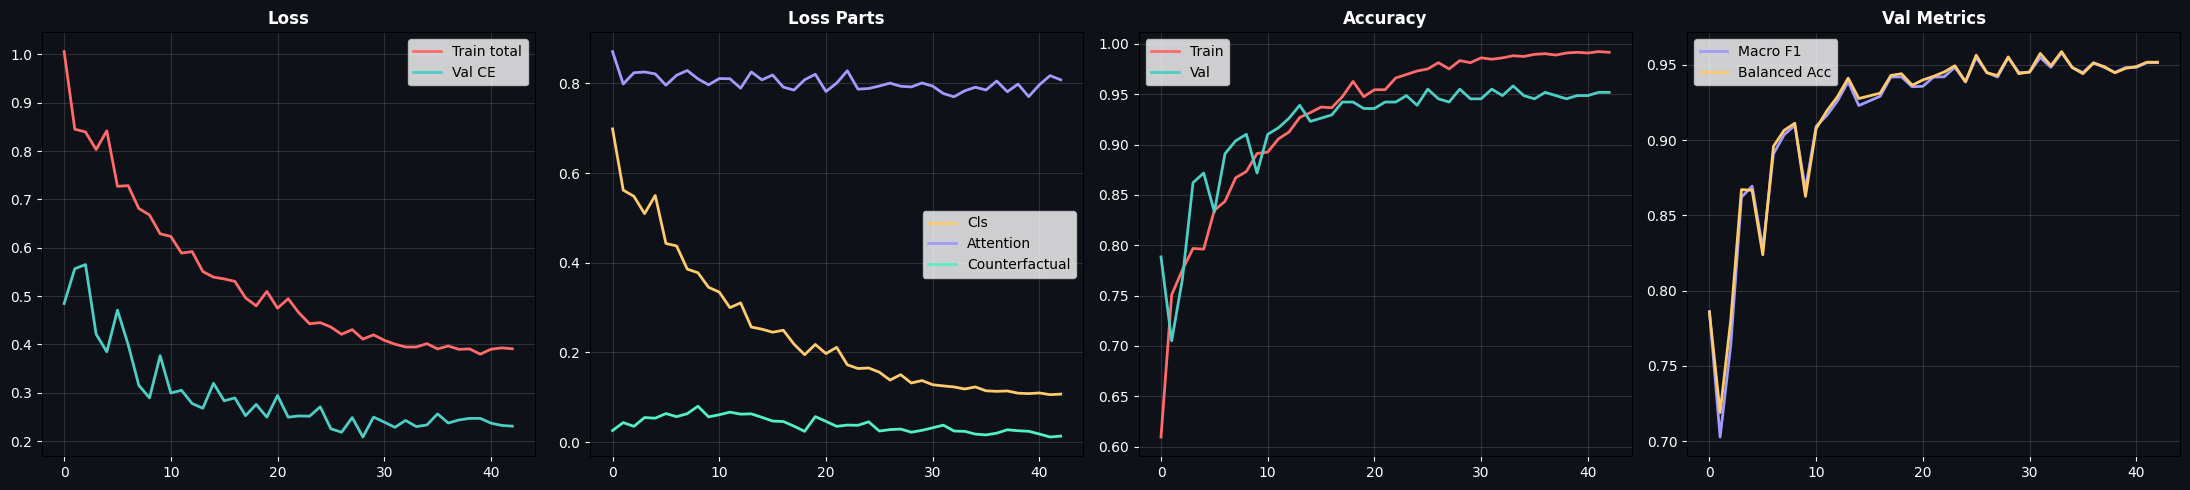

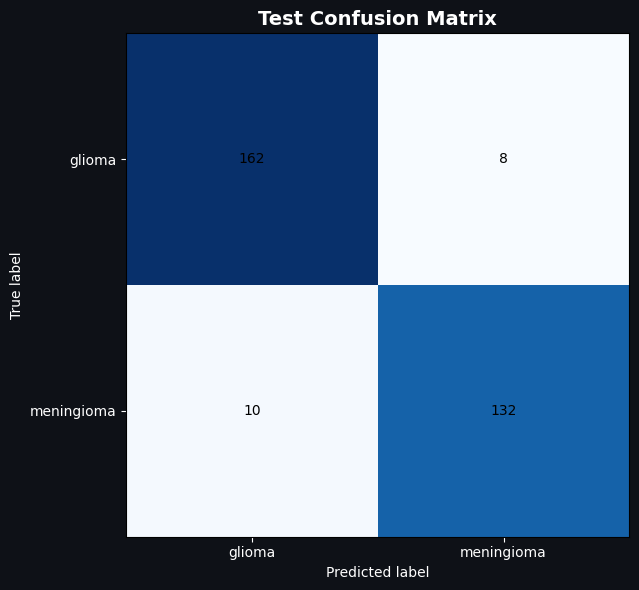

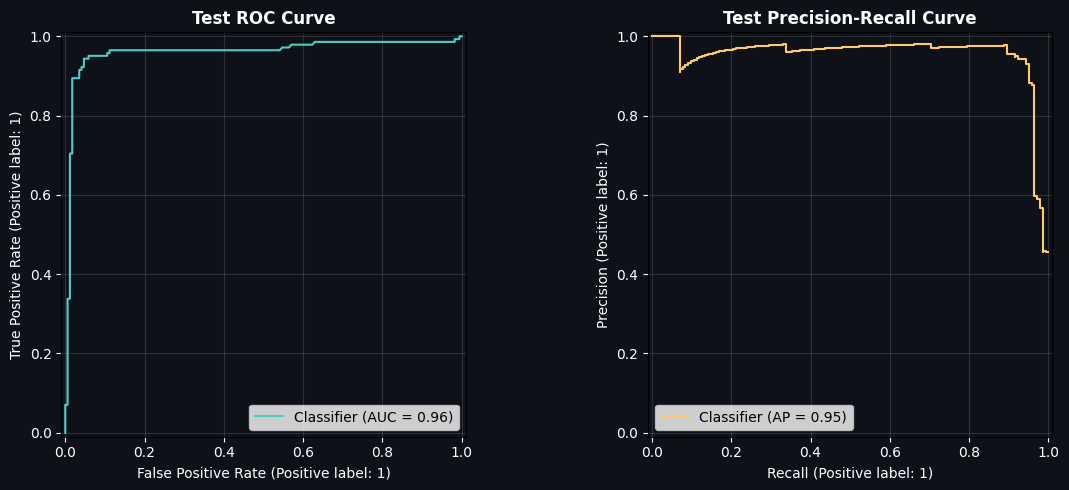

Best checkpoint: /content/drive/MyDrive/final_gli_men_3d_outputs_t1c_t2f/mask_guided_resnet18_gated_attention_raw_cache112/best_mask_guided_resnet18_gated_attention_t1c_t2f_raw112.pt


In [ ]:
CKPT = os.path.join(OUTPUT_DIR, BEST_CKPT_NAME)
best_model = build_model().to(DEVICE)
best_model.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=True))
best_model.eval()

val_m = evaluate_classifier(best_model, val_loader, device=DEVICE)
test_m = evaluate_classifier(best_model, test_loader, device=DEVICE)
print(f"Val  -> Acc={val_m['accuracy']:.4f}  F1={val_m['macro_f1']:.4f}  BA={val_m['balanced_accuracy']:.4f}")
print(f"Test -> Acc={test_m['accuracy']:.4f}  F1={test_m['macro_f1']:.4f}  BA={test_m['balanced_accuracy']:.4f}")
if "roc_auc" in test_m:
    print(f"Test binary metrics -> ROC-AUC={test_m['roc_auc']:.4f}  AP={test_m['average_precision']:.4f}  Sensitivity={test_m['sensitivity']:.4f}  Specificity={test_m['specificity']:.4f}")

labels = [INDEX_TO_CLASS[i] for i in sorted(INDEX_TO_CLASS)]
print("\nTest Classification Report:")
print(classification_report(test_m["targets"], test_m["predictions"], target_names=labels, digits=4, zero_division=0))

history = pd.read_csv(os.path.join(OUTPUT_DIR, "training_history.csv"))
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.patch.set_facecolor("#0e1117")
for ax in axes:
    ax.set_facecolor("#0e1117"); ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white"); ax.grid(alpha=0.2)
axes[0].plot(history["train_loss"], label="Train total", color="#ff6b6b", lw=2); axes[0].plot(history["val_loss"], label="Val CE", color="#4ecdc4", lw=2); axes[0].set_title("Loss", fontweight="bold"); axes[0].legend()
axes[1].plot(history["train_cls_loss"], label="Cls", color="#fdcb6e", lw=2); axes[1].plot(history["train_attn_loss"], label="Attention", color="#a29bfe", lw=2); axes[1].plot(history["train_cf_loss"], label="Counterfactual", color="#55efc4", lw=2); axes[1].set_title("Loss Parts", fontweight="bold"); axes[1].legend()
axes[2].plot(history["train_acc"], label="Train", color="#ff6b6b", lw=2); axes[2].plot(history["val_acc"], label="Val", color="#4ecdc4", lw=2); axes[2].set_title("Accuracy", fontweight="bold"); axes[2].legend()
axes[3].plot(history["val_macro_f1"], label="Macro F1", color="#a29bfe", lw=2); axes[3].plot(history["val_balanced_acc"], label="Balanced Acc", color="#fdcb6e", lw=2); axes[3].set_title("Val Metrics", fontweight="bold"); axes[3].legend()
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, facecolor="#0e1117"); plt.show()

cm = confusion_matrix(test_m["targets"], test_m["predictions"])
fig, ax = plt.subplots(figsize=(7, 6)); fig.patch.set_facecolor("#0e1117")
disp = ConfusionMatrixDisplay(cm, display_labels=labels); disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_facecolor("#0e1117"); ax.set_title("Test Confusion Matrix", color="white", fontweight="bold", fontsize=14); ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
for text in ax.texts: text.set_color("black")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, facecolor="#0e1117"); plt.show()

if "roc_auc" in test_m:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5)); fig.patch.set_facecolor("#0e1117")
    RocCurveDisplay.from_predictions(test_m["targets"], test_m["probabilities"][:, 1], ax=axes[0], color="#4ecdc4")
    PrecisionRecallDisplay.from_predictions(test_m["targets"], test_m["probabilities"][:, 1], ax=axes[1], color="#fdcb6e")
    for ax in axes:
        ax.set_facecolor("#0e1117"); ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white"); ax.grid(alpha=0.2)
    axes[0].set_title("Test ROC Curve", fontweight="bold"); axes[1].set_title("Test Precision-Recall Curve", fontweight="bold")
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "roc_pr_curves.png"), dpi=150, facecolor="#0e1117"); plt.show()

metrics_json = {"val": {k: (float(v) if np.isscalar(v) else None) for k, v in val_m.items() if k not in ["targets", "predictions", "probabilities"]}, "test": {k: (float(v) if np.isscalar(v) else None) for k, v in test_m.items() if k not in ["targets", "predictions", "probabilities"]}, "labels": INDEX_TO_CLASS}
with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w", encoding="utf-8") as f: json.dump(metrics_json, f, indent=2)
print("Best checkpoint:", CKPT)


##GRADCAM++ For Test Data Split (With MASKS)

In [ ]:
@torch.no_grad()
def counterfactual_sanity_check(model, loader, max_cases=80):
    model.eval()
    rows, seen = [], 0
    for batch in tqdm(loader, desc="Counterfactual sanity", leave=False):
        image = batch["image"].to(DEVICE)
        tumor_soft = batch["tumor_soft"].to(DEVICE)
        has_mask = batch["has_mask"].to(DEVICE) > 0.5
        labels = batch["label"].to(DEVICE)
        if not has_mask.any():
            continue
        image, tumor_soft, labels = image[has_mask], tumor_soft[has_mask], labels[has_mask]
        pids = [p for p, keep in zip(batch["patient_id"], has_mask.cpu().numpy()) if keep]
        full_probs = torch.softmax(model(image), dim=1)
        erased_probs = torch.softmax(model(image * (1.0 - tumor_soft)), dim=1)
        only_probs = torch.softmax(model(tumor_keep_image(image, tumor_soft)), dim=1)
        for i in range(image.shape[0]):
            true_cls = int(labels[i].item())
            rows.append({"patient_id": pids[i], "true_class": INDEX_TO_CLASS[true_cls], "full_true_prob": float(full_probs[i, true_cls].cpu()), "tumor_erased_true_prob": float(erased_probs[i, true_cls].cpu()), "tumor_only_true_prob": float(only_probs[i, true_cls].cpu()), "drop_when_erased": float((full_probs[i, true_cls] - erased_probs[i, true_cls]).cpu()), "drop_when_only_tumor": float((full_probs[i, true_cls] - only_probs[i, true_cls]).cpu())})
            seen += 1
            if seen >= max_cases:
                return pd.DataFrame(rows)
    return pd.DataFrame(rows)


cf_df = counterfactual_sanity_check(best_model, test_loader, max_cases=80)
if len(cf_df):
    cf_path = os.path.join(OUTPUT_DIR, "counterfactual_sanity_test.csv")
    cf_df.to_csv(cf_path, index=False)
    print(cf_df.groupby("true_class")[["full_true_prob", "tumor_erased_true_prob", "tumor_only_true_prob", "drop_when_erased", "drop_when_only_tumor"]].mean())
    print("Saved:", cf_path)
    print("Good sign: drop_when_erased should be positive, and drop_when_only_tumor should be small or negative.")
else:
    print("No masked test cases available for counterfactual sanity check.")


Counterfactual sanity:   0%|          | 0/156 [00:00<?, ?it/s]

            full_true_prob  tumor_erased_true_prob  tumor_only_true_prob  \
true_class                                                                 
glioma            0.972327                0.536007              0.926967   

            drop_when_erased  drop_when_only_tumor  
true_class                                          
glioma               0.43632               0.04536  
Saved: /content/drive/MyDrive/final_gli_men_3d_outputs_t1c_t2f/mask_guided_resnet18_gated_attention_raw_cache112/counterfactual_sanity_test.csv
Good sign: drop_when_erased should be positive, and drop_when_only_tumor should be small or negative.


In [ ]:
# Pretty Grad-CAM++ plus learned guided-attention heatmap.
# Uses ONLY TEST records with valid non-empty masks.

import matplotlib, matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

plt.style.use("dark_background")
matplotlib.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "text.color": "white",
    "font.size": 10,
})

N_GRADCAM_CASES = 12
GRADCAM_DIR = os.path.join(OUTPUT_DIR, "pretty_gradcampp_test_masked_only")
os.makedirs(GRADCAM_DIR, exist_ok=True)

def normalize01(x, eps=1e-8):
    x = np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    mn, mx = float(x.min()), float(x.max())
    return np.zeros_like(x, dtype=np.float32) if mx - mn <= eps else np.clip((x - mn) / (mx - mn), 0, 1).astype(np.float32)

def make_brain_mask(vol, eps=1e-6):
    abs_vol = np.max(np.abs(vol), axis=0)
    vals = abs_vol[abs_vol > eps]
    if vals.size < 100:
        return abs_vol > eps
    return (abs_vol >= max(float(np.percentile(vals, 5)), eps)).astype(bool)

def display_slice(x, brain=None):
    x = np.asarray(x, dtype=np.float32)
    if brain is None:
        brain = np.abs(x) > 1e-6
    vals = x[brain] if np.count_nonzero(brain) > 20 else x.reshape(-1)
    lo, hi = np.percentile(vals, [1, 99])
    if hi - lo < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    out = (np.clip(x, lo, hi) - lo) / (hi - lo)
    out[~brain] = 0
    return np.clip(out, 0, 1).astype(np.float32)

def rotate_show(x):
    return np.rot90(np.asarray(x))

def max_focus_slices(cam, seg=None, brain=None):
    score = np.asarray(cam, dtype=np.float32).copy()
    if brain is not None:
        score *= brain.astype(np.float32)
    if seg is not None and np.count_nonzero(seg) > 0:
        score = 0.65 * score + 0.35 * seg.astype(np.float32)
    if not np.isfinite(score).all() or float(score.max()) <= 0:
        d, h, w = score.shape
        return d // 2, h // 2, w // 2
    return (
        int(np.argmax(score.sum(axis=(1, 2)))),
        int(np.argmax(score.sum(axis=(0, 2)))),
        int(np.argmax(score.sum(axis=(0, 1)))),
    )

class GradCAMPlusPlus3D:
    def __init__(self, model, target_layer, smooth_sigma=1.0, eps=1e-8):
        self.model = model
        self.target_layer = target_layer
        self.smooth_sigma = smooth_sigma
        self.eps = eps
        self.acts = None
        self.grads = None
        self.hooks = [
            target_layer.register_forward_hook(self._forward_hook),
            target_layer.register_full_backward_hook(self._backward_hook),
        ]

    def _forward_hook(self, module, inputs, output):
        self.acts = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        if grad_output and grad_output[0] is not None:
            self.grads = grad_output[0].detach()

    @torch.enable_grad()
    def __call__(self, x, target_class=None):
        self.model.eval()
        self.acts = None
        self.grads = None

        x = x.detach().clone().float().to(DEVICE)
        x.requires_grad_(True)

        logits = self.model(x)
        probs = F.softmax(logits, dim=1)

        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        self.model.zero_grad(set_to_none=True)
        logits[:, target_class].sum().backward()

        if self.acts is None or self.grads is None:
            raise RuntimeError("Grad-CAM++ hooks did not capture activations/gradients.")

        acts = self.acts.float()
        grads = self.grads.float()

        grads_pos = F.relu(grads)
        grads2 = grads.pow(2)
        grads3 = grads.pow(3)

        denom = 2.0 * grads2 + (acts * grads3).sum(dim=(2, 3, 4), keepdim=True)
        denom = torch.where(torch.abs(denom) > self.eps, denom, torch.ones_like(denom) * self.eps)

        alpha = torch.where(
            torch.isfinite(grads2 / denom),
            grads2 / denom,
            torch.zeros_like(grads2),
        )

        weights = (alpha * grads_pos).sum(dim=(2, 3, 4), keepdim=True)
        cam = F.relu((weights * acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="trilinear", align_corners=False)

        cam = cam.squeeze().detach().cpu().numpy().astype(np.float32)
        if self.smooth_sigma and self.smooth_sigma > 0:
            cam = gaussian_filter(cam, sigma=self.smooth_sigma)

        return normalize01(cam), target_class, probs[0].detach().cpu().numpy()

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

@torch.no_grad()
def learned_attention_map(model, x):
    out = model(x.float().to(DEVICE), return_attention=True)
    attn = F.interpolate(out["attention"], size=x.shape[2:], mode="trilinear", align_corners=False)
    attn = attn.squeeze().detach().cpu().numpy().astype(np.float32)
    return normalize01(gaussian_filter(attn, sigma=1.0))

heat_cmap = LinearSegmentedColormap.from_list(
    "brain_heat",
    ["#000033", "#0000aa", "#0055ff", "#00ccff", "#00ff99", "#aaff00", "#ffcc00", "#ff4400", "#cc0000"],
    N=256,
)

test_masked_records = []
for rec in test_records:
    if not rec.has_mask:
        continue
    try:
        with np.load(rec.path) as data:
            has_valid_mask = (
                "image" in data
                and "mask" in data
                and tuple(data["image"].shape) == (2,) + tuple(TRAIN_SPATIAL_SIZE)
                and tuple(data["mask"].shape) == (1,) + tuple(TRAIN_SPATIAL_SIZE)
                and float(data["mask"].sum()) > 0
            )
        if has_valid_mask:
            test_masked_records.append(("test", rec))
    except Exception as exc:
        print("Skipping unreadable test cache:", rec.patient_id, exc)

print(
    "TEST masked records available:",
    len(test_masked_records),
    dict(Counter(rec.class_name for _, rec in test_masked_records)),
)

if not test_masked_records:
    raise RuntimeError("No TEST records with usable masks were found.")

by_class = defaultdict(list)
for item in test_masked_records:
    by_class[item[1].label_index].append(item)

rng = random.Random(RANDOM_SEED)
selected = []
per_class = max(1, N_GRADCAM_CASES // len(CLASS_TO_INDEX))

for ci in sorted(INDEX_TO_CLASS):
    items = by_class.get(ci, [])
    rng.shuffle(items)
    selected.extend(items[:per_class])

remaining = [x for x in test_masked_records if x not in selected]
rng.shuffle(remaining)

while len(selected) < min(N_GRADCAM_CASES, len(test_masked_records)) and remaining:
    selected.append(remaining.pop())

print("Selected TEST Grad-CAM cases:", len(selected))

gcampp = GradCAMPlusPlus3D(
    best_model,
    target_layer=best_model.encoder.layer4,
    smooth_sigma=1.0,
)

try:
    for idx, (split_name, rec) in enumerate(selected, start=1):
        with np.load(rec.path) as data:
            vol_np = data["image"].astype(np.float32)
            seg_3d = (data["mask"][0] > 0).astype(np.uint8)

        brain_3d = make_brain_mask(vol_np)
        inp = torch.from_numpy(vol_np).unsqueeze(0).to(DEVICE)

        cam, pred_cls, probs = gcampp(inp)
        attn_map = learned_attention_map(best_model, inp)

        cam = np.clip(cam * brain_3d.astype(np.float32), 0, 1)
        attn_map = np.clip(attn_map * brain_3d.astype(np.float32), 0, 1)

        x_idx, y_idx, z_idx = max_focus_slices(cam, seg=seg_3d, brain=brain_3d)

        true_name = INDEX_TO_CLASS[rec.label_index]
        pred_name = INDEX_TO_CLASS[pred_cls]
        border = "#00cc66" if pred_cls == rec.label_index else "#ff3333"

        views = [
            ("Sagittal", vol_np[:, x_idx], cam[x_idx], attn_map[x_idx], seg_3d[x_idx], brain_3d[x_idx], x_idx),
            ("Coronal", vol_np[:, :, y_idx, :], cam[:, y_idx], attn_map[:, y_idx], seg_3d[:, y_idx], brain_3d[:, y_idx], y_idx),
            ("Axial", vol_np[:, :, :, z_idx], cam[:, :, z_idx], attn_map[:, :, z_idx], seg_3d[:, :, z_idx], brain_3d[:, :, z_idx], z_idx),
        ]

        fig = plt.figure(figsize=(26, 12), facecolor="#0e1117")
        fig.patch.set_edgecolor(border)
        fig.patch.set_linewidth(4)

        conf_str = " | ".join([
            f"{INDEX_TO_CLASS[i]}: {probs[i] * 100:.1f}%"
            for i in sorted(INDEX_TO_CLASS)
        ])

        fig.suptitle(
            f"11 Mask-Guided ResNet18 Gated Attention Grad-CAM++ | TEST Case {idx}: {rec.patient_id}\n"
            f"True = {true_name} | Pred = {pred_name} ({probs[pred_cls] * 100:.1f}%)\n"
            f"{conf_str}",
            fontsize=13,
            fontweight="bold",
            color=border,
            y=0.985,
        )

        gs = gridspec.GridSpec(
            3, 6,
            figure=fig,
            hspace=0.08,
            wspace=0.05,
            top=0.82,
            bottom=0.04,
            left=0.025,
            right=0.95,
        )

        titles = ["T1c", "T2F", "Seg Mask", "T1c + Mask", "T1c + Grad-CAM++", "Guided Attention"]

        for row, (view_name, mri_2ch, cam_sl, attn_sl, seg_sl, brain_sl, slice_idx) in enumerate(views):
            t1c_show = rotate_show(display_slice(mri_2ch[0], brain_sl))
            t2f_show = rotate_show(display_slice(mri_2ch[1], brain_sl))
            seg_show = rotate_show((seg_sl > 0).astype(np.float32))
            cam_show = rotate_show(normalize01(cam_sl) * brain_sl.astype(np.float32))
            attn_show = rotate_show(normalize01(attn_sl) * brain_sl.astype(np.float32))

            panels = [
                ("gray", t1c_show),
                ("gray", t2f_show),
                ("autumn", seg_show),
                ("mask_overlay", t1c_show),
                ("cam_overlay", t1c_show),
                ("heat", attn_show),
            ]

            for col, (kind, base_img) in enumerate(panels):
                ax = fig.add_subplot(gs[row, col])
                ax.axis("off")

                if kind == "gray":
                    ax.imshow(base_img, cmap="gray", vmin=0, vmax=1)

                elif kind == "autumn":
                    ax.imshow(np.zeros_like(seg_show), cmap="gray", vmin=0, vmax=1)
                    ax.imshow(
                        np.ma.masked_where(seg_show <= 0, seg_show),
                        cmap="autumn",
                        vmin=0,
                        vmax=1,
                        interpolation="nearest",
                    )

                elif kind == "mask_overlay":
                    ax.imshow(base_img, cmap="gray", vmin=0, vmax=1)
                    ax.imshow(
                        np.ma.masked_where(seg_show <= 0, seg_show),
                        cmap="Reds",
                        alpha=0.62,
                        interpolation="nearest",
                    )
                    if np.any(seg_show > 0):
                        ax.contour(seg_show > 0, levels=[0.5], colors=["cyan"], linewidths=0.8)

                elif kind == "cam_overlay":
                    ax.imshow(base_img, cmap="gray", vmin=0, vmax=1)
                    ax.imshow(cam_show, cmap="jet", alpha=0.58, vmin=0, vmax=1)

                elif kind == "heat":
                    ax.imshow(attn_show, cmap=heat_cmap, vmin=0, vmax=1)
                    if float(attn_show.max()) > 0:
                        yy, xx = np.unravel_index(np.argmax(attn_show), attn_show.shape)
                        ax.plot(xx, yy, "w+", markersize=9, markeredgewidth=1.3)

                if row == 0:
                    ax.set_title(titles[col], color="#aaaaaa", fontsize=11, pad=6)

                if col == 0:
                    ax.text(
                        0.02,
                        0.97,
                        f"{view_name} slice {slice_idx}",
                        transform=ax.transAxes,
                        color="white",
                        fontsize=8,
                        va="top",
                        bbox=dict(boxstyle="round,pad=0.18", facecolor="#0e1117", alpha=0.75),
                    )

        save_path = os.path.join(
            GRADCAM_DIR,
            f"11_gradcampp_test_masked_{idx:02d}_{true_name}_{rec.patient_id}.png",
        )

        plt.savefig(save_path, dpi=150, facecolor="#0e1117", bbox_inches="tight")
        plt.show()
        print(f"[{idx}] saved -> {save_path}")

finally:
    gcampp.remove()

print("\nDone. TEST-only masked Grad-CAM++ figures saved to:", GRADCAM_DIR)


Output hidden; open in https://colab.research.google.com to view.

##GRADCAM On Validation Data (NO MASKS)

In [ ]:
# Grad-CAM++ on BraTS validation data: 5 GLI + 5 MEN, no masks.
# Input to classifier is still MRI-only: [1, 2, 112, 112, 112] = [T1c, T2F/FLAIR]

import matplotlib, matplotlib.gridspec as gridspec
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

VAL_FOLDERS = [
    ("ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData", "glioma"),
    ("ASNR-MICCAI-BraTS2023-MEN-Challenge-ValidationData", "meningioma"),
]
N_PER_CLASS = 5
VAL_GRADCAM_DIR = os.path.join(OUTPUT_DIR, "gradcam_validation_5gli_5men_no_masks")
os.makedirs(VAL_GRADCAM_DIR, exist_ok=True)

plt.style.use("dark_background")
matplotlib.rcParams.update({"figure.facecolor": "#0e1117", "axes.facecolor": "#0e1117", "text.color": "white", "font.size": 10})

def normalize01(x, eps=1e-8):
    x = np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    mn, mx = float(x.min()), float(x.max())
    return np.zeros_like(x, dtype=np.float32) if mx - mn <= eps else np.clip((x - mn) / (mx - mn), 0, 1).astype(np.float32)

def make_brain_mask(vol, eps=1e-6):
    abs_vol = np.max(np.abs(vol), axis=0)
    vals = abs_vol[abs_vol > eps]
    return abs_vol > eps if vals.size < 100 else (abs_vol >= max(float(np.percentile(vals, 5)), eps)).astype(bool)

def display_slice(x, brain=None):
    x = np.asarray(x, dtype=np.float32)
    if brain is None:
        brain = np.abs(x) > 1e-6
    vals = x[brain] if np.count_nonzero(brain) > 20 else x.reshape(-1)
    lo, hi = np.percentile(vals, [1, 99])
    if hi - lo < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    out = (np.clip(x, lo, hi) - lo) / (hi - lo)
    out[~brain] = 0
    return np.clip(out, 0, 1).astype(np.float32)

def rotate_show(x):
    return np.rot90(np.asarray(x))

def max_focus_slices_no_mask(cam, brain=None):
    score = np.asarray(cam, dtype=np.float32).copy()
    if brain is not None:
        score *= brain.astype(np.float32)
    if not np.isfinite(score).all() or float(score.max()) <= 0:
        d, h, w = score.shape
        return d // 2, h // 2, w // 2
    return (
        int(np.argmax(score.sum(axis=(1, 2)))),
        int(np.argmax(score.sum(axis=(0, 2)))),
        int(np.argmax(score.sum(axis=(0, 1)))),
    )

def find_modality(case_dir, modality):
    files = sorted([p for p in Path(case_dir).iterdir() if p.is_file() and p.name.lower().endswith((".nii", ".nii.gz"))])
    if modality == "t1c":
        keys = ["-t1c.", "_t1c.", "-t1ce.", "_t1ce.", "-t1gd.", "_t1gd."]
    elif modality == "t2f":
        keys = ["-t2f.", "_t2f.", "-flair.", "_flair.", "-t2w-flair.", "_t2w-flair."]
    else:
        raise ValueError(modality)
    for p in files:
        if any(k in p.name.lower() for k in keys):
            return str(p)
    return None

def load_validation_case(case_dir, class_name):
    case_dir = Path(case_dir)
    t1c_path = find_modality(case_dir, "t1c")
    t2f_path = find_modality(case_dir, "t2f")
    if t1c_path is None:
        raise FileNotFoundError(f"No T1c found in {case_dir}")
    if t2f_path is None:
        raise FileNotFoundError(f"No T2F/FLAIR found in {case_dir}")

    t1c = robust_normalize(resize_3d(load_nifti_array(t1c_path), TRAIN_SPATIAL_SIZE, order=1))
    t2f = robust_normalize(resize_3d(load_nifti_array(t2f_path), TRAIN_SPATIAL_SIZE, order=1))
    image = np.stack([t1c, t2f], axis=0).astype(np.float32)

    return {
        "case_id": case_dir.name,
        "class_name": class_name,
        "label_index": CLASS_TO_INDEX[class_name],
        "image": image,
        "t1c_path": t1c_path,
        "t2f_path": t2f_path,
    }

class GradCAMPlusPlus3D:
    def __init__(self, model, target_layer, smooth_sigma=1.0, eps=1e-8):
        self.model, self.target_layer, self.smooth_sigma, self.eps = model, target_layer, smooth_sigma, eps
        self.acts = self.grads = None
        self.hooks = [
            target_layer.register_forward_hook(self._forward_hook),
            target_layer.register_full_backward_hook(self._backward_hook),
        ]

    def _forward_hook(self, module, inputs, output):
        self.acts = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        if grad_output and grad_output[0] is not None:
            self.grads = grad_output[0].detach()

    @torch.enable_grad()
    def __call__(self, x, target_class=None):
        self.model.eval()
        self.acts = self.grads = None
        x = x.detach().clone().float().to(DEVICE)
        x.requires_grad_(True)

        logits = self.model(x)
        probs = F.softmax(logits, dim=1)
        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        self.model.zero_grad(set_to_none=True)
        logits[:, target_class].sum().backward()

        if self.acts is None or self.grads is None:
            raise RuntimeError("Grad-CAM++ hooks did not capture activations/gradients.")

        acts, grads = self.acts.float(), self.grads.float()
        grads_pos, grads2, grads3 = F.relu(grads), grads.pow(2), grads.pow(3)
        denom = 2.0 * grads2 + (acts * grads3).sum(dim=(2, 3, 4), keepdim=True)
        denom = torch.where(torch.abs(denom) > self.eps, denom, torch.ones_like(denom) * self.eps)
        alpha = torch.where(torch.isfinite(grads2 / denom), grads2 / denom, torch.zeros_like(grads2))
        weights = (alpha * grads_pos).sum(dim=(2, 3, 4), keepdim=True)

        cam = F.relu((weights * acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="trilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy().astype(np.float32)
        if self.smooth_sigma and self.smooth_sigma > 0:
            cam = gaussian_filter(cam, sigma=self.smooth_sigma)
        return normalize01(cam), target_class, probs[0].detach().cpu().numpy()

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

@torch.no_grad()
def learned_attention_map(model, x):
    out = model(x.float().to(DEVICE), return_attention=True)
    attn = F.interpolate(out["attention"], size=x.shape[2:], mode="trilinear", align_corners=False)
    return normalize01(gaussian_filter(attn.squeeze().detach().cpu().numpy().astype(np.float32), sigma=1.0))

heat_cmap = LinearSegmentedColormap.from_list(
    "brain_heat",
    ["#000033", "#0000aa", "#0055ff", "#00ccff", "#00ff99", "#aaff00", "#ffcc00", "#ff4400", "#cc0000"],
    N=256,
)

val_cases = []
for folder_name, class_name in VAL_FOLDERS:
    class_root = Path(RAW_DATA_ROOT) / folder_name
    case_dirs = sorted([p for p in class_root.iterdir() if p.is_dir()])[:N_PER_CLASS]
    for case_dir in case_dirs:
        val_cases.append(load_validation_case(case_dir, class_name))

print("Loaded validation Grad-CAM cases:", len(val_cases), dict(Counter(c["class_name"] for c in val_cases)))

gcampp = GradCAMPlusPlus3D(best_model, target_layer=best_model.encoder.layer4, smooth_sigma=1.0)
rows = []

try:
    for idx, case in enumerate(val_cases, start=1):
        case_id = case["case_id"]
        true_name = case["class_name"]
        vol_np = case["image"]

        brain_3d = make_brain_mask(vol_np)
        inp = torch.from_numpy(vol_np).unsqueeze(0).to(DEVICE)

        cam, pred_cls, probs = gcampp(inp)
        attn_map = learned_attention_map(best_model, inp)

        cam = np.clip(cam * brain_3d.astype(np.float32), 0, 1)
        attn_map = np.clip(attn_map * brain_3d.astype(np.float32), 0, 1)

        x_idx, y_idx, z_idx = max_focus_slices_no_mask(cam, brain=brain_3d)
        pred_name = INDEX_TO_CLASS[pred_cls]
        border = "#00cc66" if pred_cls == case["label_index"] else "#ff3333"

        rows.append({
            "case_id": case_id,
            "true_class": true_name,
            "pred_class": pred_name,
            "prob_glioma": float(probs[CLASS_TO_INDEX["glioma"]]),
            "prob_meningioma": float(probs[CLASS_TO_INDEX["meningioma"]]),
            "correct": bool(pred_cls == case["label_index"]),
            "t1c_path": case["t1c_path"],
            "t2f_path": case["t2f_path"],
        })

        views = [
            ("Sagittal", vol_np[:, x_idx], cam[x_idx], attn_map[x_idx], brain_3d[x_idx], x_idx),
            ("Coronal", vol_np[:, :, y_idx, :], cam[:, y_idx], attn_map[:, y_idx], brain_3d[:, y_idx], y_idx),
            ("Axial", vol_np[:, :, :, z_idx], cam[:, :, z_idx], attn_map[:, :, z_idx], brain_3d[:, :, z_idx], z_idx),
        ]

        fig = plt.figure(figsize=(22, 11), facecolor="#0e1117")
        fig.patch.set_edgecolor(border)
        fig.patch.set_linewidth(4)

        conf_str = " | ".join([f"{INDEX_TO_CLASS[i]}: {probs[i] * 100:.1f}%" for i in sorted(INDEX_TO_CLASS)])
        fig.suptitle(
            f"11 Mask-Guided ResNet18 Gated Attention Grad-CAM++ | Validation No-Mask Case {idx}: {case_id}\n"
            f"True = {true_name} | Pred = {pred_name} ({probs[pred_cls] * 100:.1f}%)\n{conf_str}",
            fontsize=13,
            fontweight="bold",
            color=border,
            y=0.985,
        )

        gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.08, wspace=0.05, top=0.82, bottom=0.04, left=0.025, right=0.95)
        titles = ["T1c", "T2F", "T1c + Grad-CAM++", "T2F + Grad-CAM++", "Guided Attention"]

        for row, (view_name, mri_2ch, cam_sl, attn_sl, brain_sl, slice_idx) in enumerate(views):
            t1c_show = rotate_show(display_slice(mri_2ch[0], brain_sl))
            t2f_show = rotate_show(display_slice(mri_2ch[1], brain_sl))
            cam_show = rotate_show(normalize01(cam_sl) * brain_sl.astype(np.float32))
            attn_show = rotate_show(normalize01(attn_sl) * brain_sl.astype(np.float32))

            panels = [
                ("gray", t1c_show),
                ("gray", t2f_show),
                ("cam", t1c_show),
                ("cam", t2f_show),
                ("heat", attn_show),
            ]

            for col, (kind, base_img) in enumerate(panels):
                ax = fig.add_subplot(gs[row, col])
                ax.axis("off")

                if kind == "gray":
                    ax.imshow(base_img, cmap="gray", vmin=0, vmax=1)
                elif kind == "cam":
                    ax.imshow(base_img, cmap="gray", vmin=0, vmax=1)
                    ax.imshow(cam_show, cmap="jet", alpha=0.58, vmin=0, vmax=1)
                elif kind == "heat":
                    ax.imshow(attn_show, cmap=heat_cmap, vmin=0, vmax=1)
                    if float(attn_show.max()) > 0:
                        yy, xx = np.unravel_index(np.argmax(attn_show), attn_show.shape)
                        ax.plot(xx, yy, "w+", markersize=9, markeredgewidth=1.3)

                if row == 0:
                    ax.set_title(titles[col], color="#aaaaaa", fontsize=11, pad=6)
                if col == 0:
                    ax.text(
                        0.02, 0.97, f"{view_name} slice {slice_idx}",
                        transform=ax.transAxes,
                        color="white",
                        fontsize=8,
                        va="top",
                        bbox=dict(boxstyle="round,pad=0.18", facecolor="#0e1117", alpha=0.75),
                    )

        save_path = os.path.join(VAL_GRADCAM_DIR, f"11_gradcampp_val_nomask_{idx:02d}_{true_name}_{pred_name}_{case_id}.png")
        plt.savefig(save_path, dpi=150, facecolor="#0e1117", bbox_inches="tight")
        plt.show()
        print(f"[{idx}] saved -> {save_path}")

finally:
    gcampp.remove()

val_gradcam_df = pd.DataFrame(rows)
csv_path = os.path.join(VAL_GRADCAM_DIR, "validation_5gli_5men_predictions.csv")
val_gradcam_df.to_csv(csv_path, index=False)

print("\nValidation no-mask predictions:")
display(val_gradcam_df)
print("\nSaved Grad-CAMs to:", VAL_GRADCAM_DIR)
print("Saved CSV:", csv_path)


Output hidden; open in https://colab.research.google.com to view.